# Collaboration and Competition

---

In this notebook, you will learn how to use the Unity ML-Agents environment for the third project of the [Deep Reinforcement Learning Nanodegree](https://www.udacity.com/course/deep-reinforcement-learning-nanodegree--nd893) program.

### 1. Start the Environment

We begin by importing the necessary packages.  If the code cell below returns an error, please revisit the project instructions to double-check that you have installed [Unity ML-Agents](https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Installation.md) and [NumPy](http://www.numpy.org/).

In [2]:
from unityagents import UnityEnvironment
import numpy as np

import torch
from collections import deque
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from ddpg_agent import MADDPG
import time

%matplotlib inline

Next, we will start the environment!  **_Before running the code cell below_**, change the `file_name` parameter to match the location of the Unity environment that you downloaded.

- **Mac**: `"path/to/Tennis.app"`
- **Windows** (x86): `"path/to/Tennis_Windows_x86/Tennis.exe"`
- **Windows** (x86_64): `"path/to/Tennis_Windows_x86_64/Tennis.exe"`
- **Linux** (x86): `"path/to/Tennis_Linux/Tennis.x86"`
- **Linux** (x86_64): `"path/to/Tennis_Linux/Tennis.x86_64"`
- **Linux** (x86, headless): `"path/to/Tennis_Linux_NoVis/Tennis.x86"`
- **Linux** (x86_64, headless): `"path/to/Tennis_Linux_NoVis/Tennis.x86_64"`

For instance, if you are using a Mac, then you downloaded `Tennis.app`.  If this file is in the same folder as the notebook, then the line below should appear as follows:
```
env = UnityEnvironment(file_name="Tennis.app")
```

In [3]:
env = UnityEnvironment(
    file_name="Tennis_Windows_x86_64/Tennis.exe",
    no_graphics=True  # faster training, no rendering
)

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [4]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

In this environment, two agents control rackets to bounce a ball over a net. If an agent hits the ball over the net, it receives a reward of +0.1.  If an agent lets a ball hit the ground or hits the ball out of bounds, it receives a reward of -0.01.  Thus, the goal of each agent is to keep the ball in play.

The observation space consists of 8 variables corresponding to the position and velocity of the ball and racket. Two continuous actions are available, corresponding to movement toward (or away from) the net, and jumping. 

Run the code cell below to print some information about the environment.

In [5]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents 
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 2
Size of each action: 2
There are 2 agents. Each observes a state with length: 24
The state for the first agent looks like: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -6.65278625 -1.5
 -0.          0.          6.83172083  6.         -0.          0.        ]


### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agents and receive feedback from the environment.

Once this cell is executed, you will watch the agents' performance, if they select actions at random with each time step.  A window should pop up that allows you to observe the agents.

Of course, as part of the project, you'll have to change the code so that the agents are able to use their experiences to gradually choose better actions when interacting with the environment!

In [6]:
for i in range(1, 6):                                      # play game for 5 episodes
    env_info = env.reset(train_mode=False)[brain_name]     # reset the environment    
    states = env_info.vector_observations                  # get the current state (for each agent)
    scores = np.zeros(num_agents)                          # initialize the score (for each agent)
    while True:
        actions = np.random.randn(num_agents, action_size) # select an action (for each agent)
        actions = np.clip(actions, -1, 1)                  # all actions between -1 and 1
        env_info = env.step(actions)[brain_name]           # send all actions to tne environment
        next_states = env_info.vector_observations         # get next state (for each agent)
        rewards = env_info.rewards                         # get reward (for each agent)
        dones = env_info.local_done                        # see if episode finished
        scores += env_info.rewards                         # update the score (for each agent)
        states = next_states                               # roll over states to next time step
        if np.any(dones):                                  # exit loop if episode finished
            break
    print('Score (max over agents) from episode {}: {}'.format(i, np.max(scores)))

Score (max over agents) from episode 1: 0.0
Score (max over agents) from episode 2: 0.0
Score (max over agents) from episode 3: 0.0
Score (max over agents) from episode 4: 0.0
Score (max over agents) from episode 5: 0.0


When finished, you can close the environment.

In [1]:
env.close()

NameError: name 'env' is not defined

### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```

In [7]:
# rest env
env_info = env.reset(train_mode=True)[brain_name]

# initialize MADDPG agent
maddpg = MADDPG(state_size=state_size, 
                action_size=action_size, 
                random_seed=42)

# TensorBoard writer - run in separate terminal:
# tensorboard --logdir=runs --port=6006
writer = SummaryWriter('runs/tennis_maddpg')

print('MADDPG agent initialized.')
print(f'Training on: {torch.device("cuda:0" if torch.cuda.is_available() else "cpu")}')

C:\Users\Danie\anaconda3\envs\drlnd\lib\site-packages\torch\cuda\__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 sm_37 compute_37.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


MADDPG agent initialized.
Training on: cuda:0


In [8]:
import subprocess
import os
import datetime
from torch.utils.tensorboard import SummaryWriter

# unique run name with timestamp → new folder per run
run_name = datetime.datetime.now().strftime('tennis_%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/{run_name}')
print(f'TensorBoard run: {run_name}')

# kill existing TensorBoard instance if already running
subprocess.run('taskkill /F /IM tensorboard.exe', 
               shell=True, capture_output=True)  # silent, no error if not running

# start TensorBoard in separate window
subprocess.Popen(
    'start cmd /k tensorboard --logdir=runs --port=6006',
    shell=True
)

print('TensorBoard started → http://localhost:6006')
print('(opens in separate terminal window)')

TensorBoard run: tennis_20260313_130542
TensorBoard started → http://localhost:6006
(opens in separate terminal window)


In [10]:
def train(n_episodes=3000, max_t=1000, print_every=100, target_score=0.5, num_workers=1, writer=writer):
    scores_deque = deque(maxlen=100)
    scores_all = []
    best_avg_score = 0.0

    # open multiple environments for parallel experience collection
    # each worker needs its own port via worker_id
    # worker_id=0 → Port 5005, worker_id=1 → Port 5006, etc.
    # NOTE: start with num_workers=1, scale up after first successful training
    envs = [env]  # worker 0 is already open
    for i in range(1, num_workers):
        e = UnityEnvironment(
            file_name="Tennis_Windows_x86_64/Tennis.exe",
            no_graphics=True,
            worker_id=i
        )
        time.sleep(3)  # wait for Unity to fully initialize before next instance
        envs.append(e)

    time.sleep(3)  # extra wait before first reset

    for episode in range(1, n_episodes + 1):
        # reset all environments
        all_env_infos = [e.reset(train_mode=True)[e.brain_names[0]] for e in envs]
        all_states    = [ei.vector_observations for ei in all_env_infos]
        all_scores    = [np.zeros(num_agents) for _ in envs]
        maddpg.reset()

        for t in range(max_t):
            # collect actions + step for every worker
            for w, (e, states, scores) in enumerate(zip(envs, all_states, all_scores)):
                actions   = maddpg.act(states, add_noise=True)
                env_info = e.step(actions)[e.brain_names[0]]
                next_states = env_info.vector_observations
                rewards     = env_info.rewards
                dones       = env_info.local_done

                c_loss, a_loss = maddpg.step(states, actions,
                                              np.array(rewards),
                                              next_states,
                                              np.array(dones))

                all_states[w]  = next_states
                all_scores[w] += rewards

                if np.any(dones):
                    break

        # use worker 0 score as episode score (representative)
        episode_score = np.max(all_scores[0])
        scores_deque.append(episode_score)
        scores_all.append(episode_score)
        avg_score = np.mean(scores_deque)

        # TensorBoard logging
        writer.add_scalar('Score/Episode',    episode_score, episode)
        writer.add_scalar('Score/Average100', avg_score,     episode)
        writer.add_scalar('Buffer/Size',      len(maddpg.memory), episode)
        writer.add_scalar('Loss/Critic', c_loss, episode)
        writer.add_scalar('Loss/Actor',  a_loss, episode)

        if episode % print_every == 0:
            print(f'Episode {episode:4d} | '
                  f'Score: {episode_score:.4f} | '
                  f'Avg(100): {avg_score:.4f} | '
                  f'Buffer: {len(maddpg.memory)}')

        # save best model
        if avg_score > best_avg_score:
            best_avg_score = avg_score
            maddpg.save()
            writer.add_scalar('Score/BestAvg', best_avg_score, episode)

        # solved!
        if avg_score >= target_score and episode >= 100:
            print(f'\nSolved in episode {episode}! Avg Score: {avg_score:.4f}')
            maddpg.save()
            break

    writer.close()

    # close additional workers
    for e in envs[1:]:
        e.close()

    return scores_all

scores = train(num_workers=1, writer=writer) # erros within more :(

Episode  100 | Score: 2.1700 | Avg(100): 1.4822 | Buffer: 202000

Solved in episode 100! Avg Score: 1.4822


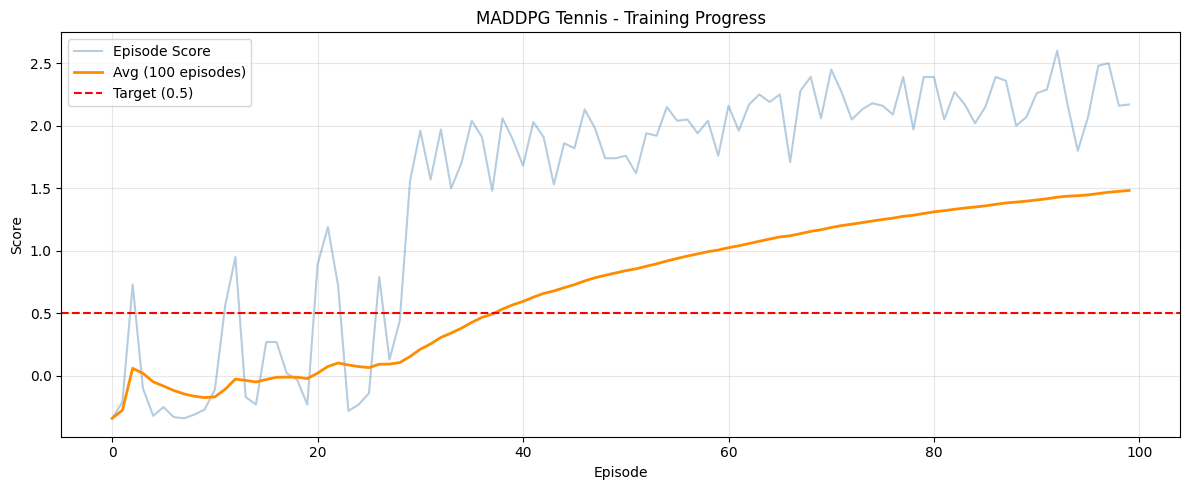

Plot saved as training_plot.png


In [11]:
def plot_scores(scores):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # raw episode scores
    ax.plot(scores, alpha=0.4, color='steelblue', label='Episode Score')
    
    # 100-episode moving average
    if len(scores) >= 100:
        moving_avg = [np.mean(scores[max(0, i-100):i+1]) 
                      for i in range(len(scores))]
        ax.plot(moving_avg, color='darkorange', linewidth=2, label='Avg (100 episodes)')
    
    # target line
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Target (0.5)')
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Score')
    ax.set_title('MADDPG Tennis - Training Progress')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_plot.png', dpi=150)
    plt.show()
    print('Plot saved as training_plot.png')

plot_scores(scores)